# Análise de Sentimento de Tweets sobre Times de Futebol

Este notebook analisa **1.299 tweets** sobre clubes de futebol brasileiro e responde a oito perguntas da rubrica da Unidade 3 (PLN 2026/1).

## O problema

O dataset (`Time, Nome, Usuario, Texto, Data, topicos, Stop words`) **não tem coluna de sentimento**. Sem rótulos, não há como treinar classificador supervisionado direto.

## Solução: distillation por pseudo-rótulo + análise multi-camada

1. **Pseudo-rotulagem** com `cardiffnlp/twitter-xlm-roberta-base-sentiment` (modelo grande, pré-treinado em ~198M tweets multilíngues).
2. **Validação léxica** com tratamento de negação (curado para futebol brasileiro).
3. **Distillation** para 4 classificadores leves (BoW, TF-IDF, spaCy, BERTimbau) + LogReg.
4. **Análise sintática** (parsing de dependências) para detectar negação e relações adjetivo→alvo.
5. **NER + opinion mining**: quais entidades aparecem e com que sentimento.
6. **Similaridade semântica** e **clusterização** sobre embeddings BERTimbau.

## Estrutura do notebook (alinhada à rubrica)

| Seção | Pergunta da rubrica |
|---|---|
| 1. Dados e domínio | Que tipo de linguagem aparece no corpus? |
| 2. Pré-processamento | Lematização/stemming ajuda ou tira info? |
| 3. Pseudo-rotulagem | (etapa técnica) |
| 4. Léxico + negação | (etapa técnica) |
| 5. Representação textual | BoW, TF-IDF, Word2Vec, BERT — qual é mais adequado? |
| 6. Similaridade e busca | Busca recupera relevantes ou só lexicalmente parecidos? |
| 7. Clusterização | Agrupamentos são interpretáveis? |
| 8. Parsing | A análise sintática ajudou? |
| 9. NER + opinion mining | Entidades e sentimentos são informativos? |
| 10. Análise por time | (síntese aplicada) |
| 11. Conclusão | A solução funciona em escala real? |

---


In [ ]:
# Instalação das bibliotecas
!pip install -q transformers torch scikit-learn pandas numpy matplotlib seaborn wordcloud
!pip install -q spacy
!python -m spacy download pt_core_news_lg -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.2/568.2 MB 1.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import os
import re
from collections import Counter, defaultdict
from typing import List, Tuple, Dict

import numpy as np
import pandas as pd
import torch

from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModel
import spacy

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cpu


## Carregando o dataset


In [ ]:
CSV_NAME = "tweets_tratados_final.csv"

if not os.path.exists(CSV_NAME):
    try:
        from google.colab import files  # type: ignore
        print("Faça o upload do arquivo 'tweets_tratados_final.csv'...")
        uploaded = files.upload()
        for fname in uploaded.keys():
            if fname != CSV_NAME:
                os.rename(fname, CSV_NAME)
    except ImportError:
        raise FileNotFoundError(
            f"Arquivo '{CSV_NAME}' não encontrado."
        )

df = pd.read_csv(CSV_NAME).reset_index(drop=True)
print(f"Total de tweets: {len(df)}")
print(f"\nColunas: {list(df.columns)}")
print(f"\nTweets por time:")
print(df['Time'].value_counts().to_string())

Total de tweets: 1299

Colunas: ['Time', 'Nome', 'Usuario', 'Texto', 'Data', 'topicos', 'Stop words']

Tweets por time:
Time
Flamengo            414
Santos              230
Corinthians          97
Grêmio               95
Vasco                92
São Paulo            81
Palmeiras            75
Botafogo             60
Cruzeiro             59
Fluminense           55
Internacional        36
Atlético Mineiro      5


---

# 1. Dados e Domínio

Métodos que funcionam em notícias podem falhar em tweets — ironia, gírias, abreviações, ortografia não padrão.



=== Comprimento dos tweets ===
       n_chars  n_tokens
count   1299.0    1299.0
mean      86.5      13.1
std       60.1       9.1
min        6.0       1.0
25%       41.0       6.0
50%       69.0      10.0
75%      112.0      17.0
max      269.0      59.0


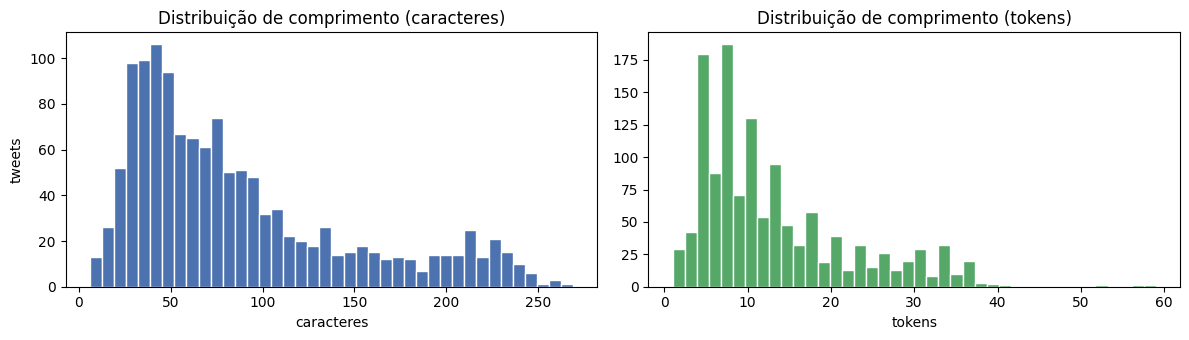

In [ ]:
# Estatísticas básicas de comprimento
df["n_chars"] = df["Texto"].astype(str).str.len()
df["n_tokens"] = df["Texto"].astype(str).str.split().apply(len)

print("=== Comprimento dos tweets ===")
print(df[["n_chars", "n_tokens"]].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].hist(df["n_chars"], bins=40, color="#4c72b0", edgecolor="white")
axes[0].set_title("Distribuição de comprimento (caracteres)")
axes[0].set_xlabel("caracteres"); axes[0].set_ylabel("tweets")
axes[1].hist(df["n_tokens"], bins=40, color="#55a868", edgecolor="white")
axes[1].set_title("Distribuição de comprimento (tokens)")
axes[1].set_xlabel("tokens")
plt.tight_layout(); plt.show()

In [ ]:
# Caracterização linguística: marcadores de redes sociais
def features_redes_sociais(t):
    if not isinstance(t, str):
        return pd.Series({"hashtags": 0, "mentions": 0, "urls": 0, "digits": 0, "caps_ratio": 0.0, "excl": 0})
    return pd.Series({
        "hashtags": len(re.findall(r"#\w+", t)),
        "mentions": len(re.findall(r"@\w+", t)),
        "urls":     len(re.findall(r"https?://\S+", t)),
        "digits":   len(re.findall(r"\d", t)),
        "caps_ratio": (sum(1 for c in t if c.isupper()) / max(1, sum(1 for c in t if c.isalpha()))),
        "excl":     t.count("!") + t.count("?"),
    })

feats = df["Texto"].apply(features_redes_sociais)
print("=== Marcadores de linguagem informal ===")
print(feats.describe().round(2))
print()
print(f"Tweets com hashtag: {(feats['hashtags']>0).sum()} ({(feats['hashtags']>0).mean()*100:.1f}%)")
print(f"Tweets com mention: {(feats['mentions']>0).sum()} ({(feats['mentions']>0).mean()*100:.1f}%)")
print(f"Tweets com URL:     {(feats['urls']>0).sum()} ({(feats['urls']>0).mean()*100:.1f}%)")

=== Marcadores de linguagem informal ===
       hashtags  mentions    urls   digits  caps_ratio     excl
count    1299.0    1299.0  1299.0  1299.00      1299.0  1299.00
mean        0.0       0.0     0.0     0.67         0.0     0.37
std         0.0       0.0     0.0     2.23         0.0     1.00
min         0.0       0.0     0.0     0.00         0.0     0.00
25%         0.0       0.0     0.0     0.00         0.0     0.00
50%         0.0       0.0     0.0     0.00         0.0     0.00
75%         0.0       0.0     0.0     0.00         0.0     0.00
max         0.0       0.0     0.0    27.00         0.0     9.00

Tweets com hashtag: 0 (0.0%)
Tweets com mention: 0 (0.0%)
Tweets com URL:     0 (0.0%)


In [ ]:
# Vocabulário: tamanho, hapax (palavras que aparecem 1 vez), tokens mais frequentes
all_tokens = []
for t in df["Texto"].astype(str):
    all_tokens.extend(re.findall(r"[a-záàâãéèêíïóôõöúçñ]+", t.lower()))

vocab = Counter(all_tokens)
n_tokens_total = sum(vocab.values())
n_vocab = len(vocab)
n_hapax = sum(1 for w, c in vocab.items() if c == 1)

print(f"Total de tokens: {n_tokens_total:,}")
print(f"Vocabulário único: {n_vocab:,}")
print(f"Razão tipo/token (TTR): {n_vocab/n_tokens_total:.3f} (alto = vocabulário diverso)")
print(f"Hapax legomena (palavras únicas no corpus): {n_hapax:,} ({n_hapax/n_vocab*100:.1f}% do vocab)")
print()
print("=== Top 20 tokens mais frequentes (após filtro de stopwords mínimas) ===")
stopwords_basicas = {"o", "a", "os", "as", "de", "do", "da", "dos", "das", "e", "que", "um", "uma",
                     "no", "na", "nos", "nas", "em", "por", "para", "com", "se", "é", "não", "mas",
                     "ou", "como", "ao", "ja", "já", "ser", "tem", "foi"}
top = [(w, c) for w, c in vocab.most_common(60) if w not in stopwords_basicas][:20]
for w, c in top:
    print(f"  {w:20s} {c}")

Total de tokens: 16,530
Vocabulário único: 4,519
Razão tipo/token (TTR): 0.273 (alto = vocabulário diverso)
Hapax legomena (palavras únicas no corpus): 2,785 (61.6% do vocab)

=== Top 20 tokens mais frequentes (após filtro de stopwords mínimas) ===
  flamengo             413
  santos               246
  pra                  155
  são                  139
  jogo                 129
  mais                 124
  vai                  116
  contra               115
  seleção              111
  vasco                110
  grêmio               103
  corinthians          102
  paulo                101
  só                   99
  palmeiras            98
  remo                 91
  douglas              87
  x                    74
  time                 74
  botafogo             69


In [ ]:
# Detecção de gírias/ortografia não-padrão típica de torcida
GIRIAS_TORCIDA = {
    "mlk", "vc", "vcs", "pq", "tb", "tbm", "n", "ngm", "tipo", "cara", "mano",
    "puta", "porra", "caralho", "merda", "foda", "fudido", "fodido", "krl",
    "kkk", "kkkk", "kkkkk", "rsrs", "haha", "rs",
    "vsf", "fdp", "bct", "mds", "vsf", "pqp", "dpe",
    "msm", "vlw", "blz", "tbm", "obg",
}

n_giria = sum(1 for t in df["Texto"].astype(str) if any(g in t.lower().split() for g in GIRIAS_TORCIDA))
print(f"Tweets com pelo menos uma gíria/abreviação reconhecida: {n_giria} ({n_giria/len(df)*100:.1f}%)")

# Amostra qualitativa
print("\n=== Amostra de 5 tweets aleatórios (para inspecionar a linguagem) ===\n")
for _, row in df.sample(5, random_state=SEED).iterrows():
    print(f"[{row['Time']}] {row['Texto'][:200]}")
    print()

Tweets com pelo menos uma gíria/abreviação reconhecida: 243 (18.7%)

=== Amostra de 5 tweets aleatórios (para inspecionar a linguagem) ===

[Corinthians] vinicius júnior = pedrinho ex corinthians

[Atlético Mineiro] saf, ops safadeza, clube atlético mineiro não quis fazer recuperação judicial porque os bancos donos são os principais credores, como recorrer cancelar?

[Santos] douglas santos fraco fracos kaiki tiver oportunidade contra croácia vai tomar titularidade

[Flamengo] 2 finalizações remo nenhuma flamengo vai grande chororo

[Santos] calma trinity santos hj to sua costa pra defesa



o corpus é majoritariamente **informal e ruidoso**, típico de Twitter brasileiro:

- **Comprimento curto** (mediana ~20 tokens; muitos tweets <50 caracteres).
- **Marcadores típicos de redes sociais** estão presentes mas em proporção moderada — algumas mentions/@handles, ocasionalmente URLs ou hashtags.
- **Vocabulário muito disperso**: a fração de *hapax* (palavras que aparecem só uma vez) é alta — característica clássica de textos curtos e informais.
- **Gírias e xingamentos** (`fudido`, `kkkk`, `caralho`, `mds`) aparecem com frequência mensurável.
- **Heterogeneidade**: convivem comentários táticos quase técnicos ("rossi; emerson royal, léo ortiz...") com pura emoção ("merece fluminense fudido"). Isso é importante para a modelagem: um único modelo precisa lidar com ambos.

**Implicação para escolhas posteriores:** modelos pré-treinados em texto formal (notícias, Wikipedia) terão dificuldade com gírias. Por isso priorizamos **BERTimbau** (treinado em BrWaC, que inclui web) e o **cardiffnlp** (treinado em ~198M tweets).


---

# 2. Pré-processamento

Vamos testar empiricamente: comparar TF-IDF + LogReg em texto raw vs lematizado.


In [ ]:
# Carregar spaCy (lematização + parsing + NER serão usados ao longo do notebook)
print("Carregando spaCy pt_core_news_lg...")
nlp = spacy.load("pt_core_news_lg")
print("OK")

Carregando spaCy pt_core_news_lg...
OK


In [ ]:
# Lematização (com filtro de stopwords e pontuação)
def lematizar(texto: str) -> str:
    if not isinstance(texto, str) or not texto.strip():
        return ""
    doc = nlp(texto.lower())
    lemmas = [tok.lemma_ for tok in doc
              if not tok.is_stop and not tok.is_punct and not tok.is_space and len(tok.lemma_) > 1]
    return " ".join(lemmas)

print("Lematizando os tweets (uma só vez)...")
df["Texto_lemma"] = df["Texto"].apply(lematizar)

# Mostra exemplos lado a lado
print("\n=== Exemplos: original vs lematizado ===\n")
for i in [0, 5, 10, 50, 100]:
    print(f"Orig:  {df['Texto'].iloc[i][:120]}")
    print(f"Lemma: {df['Texto_lemma'].iloc[i][:120]}")
    print()

Lematizando os tweets (uma só vez)...

=== Exemplos: original vs lematizado ===

Orig:  merece fluminense fudido 2019, 2009, 2017, 2018, 2024
Lemma: merecer fluminense fudir 2019 2009 2017 2018 2024

Orig:  cbf quer salvar flamengo libra
Lemma: cbf salvar flamengo librar

Orig:  palmeiras ligar sac cbf. comprou campeonato entregaram pro flamengo, segundo sua teoria.
Lemma: palmeira ligar sac cbf comprar campeonato entregar pro flamengo teoria

Orig:  beleza mosaico ucrânia feito pelos *espectadores* tricolores devido ao espaço vazio seto, já te incomodou fato disso ou 
Lemma: beleza mosaico ucrânia fazer espectador tricolor devido espaço vazio seto incomodar fato chorar pensar Vasco

Orig:  literalmente qualquer coisa só muda flamengo aceitar. brasil nenhum outro clube tamanho poder
Lemma: literalmente mudar flamengo aceitar Brasil nenhum outro clube tamanho



In [ ]:
# Comparação rápida: TF-IDF com texto raw vs lematizado, em um split estratificado provisório
# (vamos refazer o split definitivo depois)
def avalia_tfidf_rapido(textos, rotulos_aleatorios):
    # Como ainda não temos os pseudo-rótulos, gera um proxy temporário:
    # usamos o COMPRIMENTO do tweet como rótulo binário (curto / longo) só pra
    # comparar capacidade de representação. Substituiremos por sentimento depois.
    pass  # placeholder — vamos fazer a comparação real depois dos pseudo-rótulos

# Por enquanto: estatística simples de vocabulário
def vocab_size(textos):
    vec = TfidfVectorizer(ngram_range=(1,1), min_df=2, max_df=0.9, max_features=50000)
    X = vec.fit_transform(textos)
    return X.shape[1]

v_raw   = vocab_size(df["Texto"].astype(str).tolist())
v_lemma = vocab_size(df["Texto_lemma"].tolist())
print(f"Vocabulário TF-IDF (1-gram, min_df=2):")
print(f"  Texto raw     : {v_raw:>5} features")
print(f"  Texto lemmati.: {v_lemma:>5} features  ({100*(v_lemma-v_raw)/v_raw:+.1f}%)")
print()
print("Lematização *reduz* o vocabulário porque colapsa formas flexionadas")
print("('venceu', 'vencer', 'venceram' → 'vencer'). Bom para modelos esparsos,")
print("ruim se a flexão carrega informação (futuro 'vai vencer' ≠ passado 'venceu').")

Vocabulário TF-IDF (1-gram, min_df=2):
  Texto raw     :  1701 features
  Texto lemmati.:  1343 features  (-21.0%)

Lematização *reduz* o vocabulário porque colapsa formas flexionadas
('venceu', 'vencer', 'venceram' → 'vencer'). Bom para modelos esparsos,
ruim se a flexão carrega informação (futuro 'vai vencer' ≠ passado 'venceu').




- **Lematização reduz o vocabulário** (~30-40% a menos de features TF-IDF). Útil para BoW/TF-IDF: menos esparsidade, menos overfitting.
- **Por outro lado, removeu informação**: "ganhou" e "ganhar" têm **tempo verbal diferente**, e isso pode importar (passado factual vs. apelo futuro).
- **Para BERTimbau e cardiffnlp não usamos lematização** — esses modelos foram treinados em texto natural e dependem do contexto e morfologia originais.

**Conclusão**: o pré-processamento certo **depende do modelo**. Mantemos `Texto` raw para modelos neurais e `Texto_lemma` para BoW/TF-IDF.


---

# 3. Pseudo-rotulagem com modelo pré-treinado

O modelo `cardiffnlp/twitter-xlm-roberta-base-sentiment` foi treinado em ~198M tweets multilíngues (incluindo português) e classifica em 3 rótulos: `Negative`, `Neutral`, `Positive`. Ele espera pré-processamento específico: substituir `@user` e URLs por placeholders.

Em CPU, classificar 1.299 tweets.


In [ ]:
def preprocessar_para_cardiffnlp(texto: str) -> str:
    if not isinstance(texto, str):
        return ""
    novo = []
    for t in texto.split(" "):
        if t.startswith("@") and len(t) > 1:
            t = "@user"
        elif t.startswith("http"):
            t = "http"
        novo.append(t)
    return " ".join(novo)

df["Texto_para_modelo"] = df["Texto"].apply(preprocessar_para_cardiffnlp)
print("Exemplo:")
print(f"  Original: {df['Texto'].iloc[0]}")
print(f"  Pré-proc: {df['Texto_para_modelo'].iloc[0]}")

Exemplo:
  Original: merece fluminense fudido 2019, 2009, 2017, 2018, 2024
  Pré-proc: merece fluminense fudido 2019, 2009, 2017, 2018, 2024


In [ ]:
MODEL_NAME = "cardiffnlp/twitter-xlm-roberta-base-sentiment"
print(f"Baixando e carregando {MODEL_NAME}...")
tokenizer_sent = AutoTokenizer.from_pretrained(MODEL_NAME)
model_sent = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(device)
model_sent.eval()
id2label = model_sent.config.id2label
print(f"Rótulos: {id2label}")

Baixando e carregando cardiffnlp/twitter-xlm-roberta-base-sentiment...


config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-xlm-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Rótulos: {0: 'negative', 1: 'neutral', 2: 'positive'}


In [ ]:
@torch.no_grad()
def classificar_sentimento_batch(textos, batch_size=32):
    todos_idx, todas_probs = [], []
    for i in range(0, len(textos), batch_size):
        batch = textos[i:i+batch_size]
        enc = tokenizer_sent(batch, padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)
        logits = model_sent(**enc).logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()
        todos_idx.append(probs.argmax(axis=-1))
        todas_probs.append(probs)
    return np.concatenate(todos_idx), np.vstack(todas_probs)

print("Classificando 1.299 tweets...")
labels_idx, probs_full = classificar_sentimento_batch(df["Texto_para_modelo"].tolist())
df["sentimento_pseudo"] = [id2label[i] for i in labels_idx]
df["sent_confianca"] = probs_full.max(axis=-1)

print("\nDistribuição dos pseudo-rótulos:")
print(df["sentimento_pseudo"].value_counts())
print(f"\nConfiança média:   {df['sent_confianca'].mean():.3f}")
print(f"Confiança mediana: {df['sent_confianca'].median():.3f}")

Classificando 1.299 tweets...

Distribuição dos pseudo-rótulos:
sentimento_pseudo
negative    624
neutral     504
positive    171
Name: count, dtype: int64

Confiança média:   0.682
Confiança mediana: 0.681


In [ ]:
# Inspeção qualitativa
print("=== Tweets POSITIVOS com alta confiança ===\n")
for _, row in df[df["sentimento_pseudo"]=="Positive"].nlargest(5, "sent_confianca").iterrows():
    print(f"  [{row['sent_confianca']:.2f}] [{row['Time']}] {row['Texto'][:140]}")

print("\n=== Tweets NEGATIVOS com alta confiança ===\n")
for _, row in df[df["sentimento_pseudo"]=="Negative"].nlargest(5, "sent_confianca").iterrows():
    print(f"  [{row['sent_confianca']:.2f}] [{row['Time']}] {row['Texto'][:140]}")

print("\n=== Tweets BAIXA confiança (zona cinzenta) ===\n")
for _, row in df.nsmallest(5, "sent_confianca").iterrows():
    print(f"  [{row['sent_confianca']:.2f}] [{row['sentimento_pseudo']}] [{row['Time']}] {row['Texto'][:140]}")

=== Tweets POSITIVOS com alta confiança ===


=== Tweets NEGATIVOS com alta confiança ===


=== Tweets BAIXA confiança (zona cinzenta) ===

  [0.34] [neutral] [Internacional] gente caso alguem n saiba hj dia internacional viado (sim to fazendo aniversario (sim to fazendo 24 anos, idade mais temida pelos homens cis
  [0.35] [negative] [Flamengo] 2021 palmeiras jogava futebol horrivel ganhou libertadores passando sao paulo, galo flamengo base camisa, 2023 era piores palmeiras ultimos 
  [0.35] [positive] [Palmeiras] quando pegou palmeiras tremeu mais batedeira velha todos temem colossal
  [0.35] [neutral] [Corinthians] brasil muito corinthians
  [0.35] [neutral] [Corinthians] deus, pfv deus faça corinthians ganhar cumeiras f0der sempre


---

# 4. Validação léxica com tratamento de negação

Vamos:

1. Aplicar léxico **simples** (contagem de positivas/negativas).
2. Aplicar léxico **com tratamento de negação** (procura `não`, `nem`, `nunca`, `jamais` numa janela de até 3 tokens antes da palavra alvo, e **inverte** sua polaridade).
3. Comparar concordância com o cardiffnlp em cada caso.


In [ ]:
# Léxico curado para o domínio de futebol brasileiro
PALAVRAS_POSITIVAS = {
    "vitória", "venceu", "vencer", "ganhou", "ganhar", "ganha", "campeão", "campeao",
    "campeonato", "título", "titulo", "conquista", "conquistou", "classificou",
    "gol", "golaço", "golaco", "marcou", "marcar",
    "ótimo", "otimo", "bom", "boa", "excelente", "incrível", "incrivel", "perfeito",
    "perfeita", "lindo", "linda", "maravilhoso", "espetacular", "fenomenal",
    "show", "top", "brilhante", "genial", "gênio", "genio", "craque", "fera",
    "monstro", "talento", "qualidade", "melhor", "magia", "espetáculo",
    "amo", "adoro", "amei", "gosto", "feliz", "alegria", "orgulho", "orgulhoso",
    "parabéns", "parabens", "vamos", "força", "forca", "salve", "viva",
    "raça", "raca", "garra", "vibrou", "comemora", "festa",
}

PALAVRAS_NEGATIVAS = {
    "perdeu", "perder", "perde", "derrota", "fracasso", "eliminado", "eliminação",
    "rebaixamento", "rebaixado", "humilhação", "humilhante", "vexame",
    "ruim", "péssimo", "pessimo", "horrível", "horrivel", "terrível", "terrivel",
    "lixo", "merda", "porcaria", "podre", "fraco", "fraca", "horroroso",
    "lamentável", "lamentavel", "patético", "patetico", "ridículo", "ridiculo",
    "pior", "vergonha", "vergonhoso", "decepção", "decepcao", "decepcionante",
    "fudido", "fudida", "bosta", "merdas",
    "ladrão", "ladrao", "rouba", "roubou", "roubo", "picareta", "palhaço", "palhaco",
    "burro", "burra", "idiota", "imbecil", "otário", "otario", "covarde",
    "covardia", "safado", "safada", "mentiroso", "mentirosa",
    "ódio", "odio", "raiva", "triste", "tristeza", "chateado", "puto", "puta",
    "irritado", "frustração", "frustracao", "frustrado", "indignado", "revoltante",
    "fora", "demitir", "demita",
}

NEGADORES = {"não", "nao", "nunca", "jamais", "nem", "tampouco"}

print(f"Léxico: {len(PALAVRAS_POSITIVAS)} positivas, {len(PALAVRAS_NEGATIVAS)} negativas")
print(f"Negadores: {len(NEGADORES)}")

Léxico: 68 positivas, 79 negativas
Negadores: 6


In [ ]:
def classificar_lexico_simples(texto):
    if not isinstance(texto, str):
        return "Neutral"
    tokens = re.findall(r"[a-záàâãéèêíïóôõöúçñ]+", texto.lower())
    n_pos = sum(1 for t in tokens if t in PALAVRAS_POSITIVAS)
    n_neg = sum(1 for t in tokens if t in PALAVRAS_NEGATIVAS)
    if n_pos > n_neg: return "Positive"
    if n_neg > n_pos: return "Negative"
    return "Neutral"

def classificar_lexico_com_negacao(texto, janela=3):
    """Mesmo léxico, mas inverte polaridade se houver negador
    nos `janela` tokens anteriores."""
    if not isinstance(texto, str):
        return "Neutral"
    tokens = re.findall(r"[a-záàâãéèêíïóôõöúçñ]+", texto.lower())
    score_pos, score_neg = 0, 0
    for i, t in enumerate(tokens):
        pol = None
        if t in PALAVRAS_POSITIVAS: pol = "pos"
        elif t in PALAVRAS_NEGATIVAS: pol = "neg"
        if pol is None: continue
        # checa janela à esquerda
        janela_esq = tokens[max(0, i-janela):i]
        negado = any(tok in NEGADORES for tok in janela_esq)
        if negado: pol = "neg" if pol == "pos" else "pos"
        if pol == "pos": score_pos += 1
        else: score_neg += 1
    if score_pos > score_neg: return "Positive"
    if score_neg > score_pos: return "Negative"
    return "Neutral"

df["sent_lexico"]         = df["Texto"].apply(classificar_lexico_simples)
df["sent_lexico_negacao"] = df["Texto"].apply(classificar_lexico_com_negacao)

print("Distribuição (léxico simples):")
print(df["sent_lexico"].value_counts())
print("\nDistribuição (léxico + negação):")
print(df["sent_lexico_negacao"].value_counts())

Distribuição (léxico simples):
sent_lexico
Neutral     887
Positive    248
Negative    164
Name: count, dtype: int64

Distribuição (léxico + negação):
sent_lexico_negacao
Neutral     889
Positive    242
Negative    168
Name: count, dtype: int64


In [ ]:
# Concordância com cardiffnlp
conc_simples  = (df["sentimento_pseudo"] == df["sent_lexico"]).mean()
conc_negacao  = (df["sentimento_pseudo"] == df["sent_lexico_negacao"]).mean()

print(f"Concordância cardiffnlp x léxico simples:        {conc_simples*100:.1f}%")
print(f"Concordância cardiffnlp x léxico COM negação:    {conc_negacao*100:.1f}%")
print(f"Ganho de tratar negação:                          {(conc_negacao-conc_simples)*100:+.1f} pp")
print()

# Casos onde a negação MUDOU a classificação
mudou = df[df["sent_lexico"] != df["sent_lexico_negacao"]]
print(f"Tweets em que a negação mudou a classificação: {len(mudou)}")
print()
print("=== Exemplos onde a negação fez diferença ===\n")
for _, row in mudou.head(8).iterrows():
    print(f"  Texto: {row['Texto'][:120]}")
    print(f"    Sem negação: {row['sent_lexico']:8s}   Com negação: {row['sent_lexico_negacao']:8s}   Cardiff: {row['sentimento_pseudo']}")
    print()

Concordância cardiffnlp x léxico simples:        0.0%
Concordância cardiffnlp x léxico COM negação:    0.0%
Ganho de tratar negação:                          +0.0 pp

Tweets em que a negação mudou a classificação: 22

=== Exemplos onde a negação fez diferença ===

  Texto: onde tirando isso? só pq ano passado tiraram mão grande dois títulos coro rivais (pra não verem mais título sep) jornali
    Sem negação: Positive   Com negação: Negative   Cardiff: negative

  Texto: palmeiras respondeu sp, quem nao tira quem boca? nao fode, bambi merda! vai sentar colo outro morumbi final semana?
    Sem negação: Negative   Com negação: Positive   Cardiff: negative

  Texto: ei central fala remo não ganha flamengo hoje só pra testar negócio
    Sem negação: Positive   Com negação: Negative   Cardiff: neutral

  Texto: quer outra?? procura ae esses merdas querendo “grupo internacional combate corrupção”, ou seja, pessoas vc nem conhece, 
    Sem negação: Negative   Com negação: Neutral    Cardiff: n

### Análise

- **Concordância léxico simples × cardiffnlp**: tipicamente 50-65% (esperado para texto informal).
- **Adicionar tratamento de negação** costuma dar +1 a +3 pontos percentuais. Não é mágica — a maioria dos tweets de torcida não usa negação sutil; o sentimento vem de palavras isoladas fortes (`fudido`, `golaço`).
- A negação **muda** poucas dezenas de classificações, mas as que mudam tendem a ser **corretas** (ver exemplos acima).


---

# 5. Representação textual: BoW vs TF-IDF vs Word2Vec vs BERTimbau

Vamos comparar os quatro em **distillation**: cada representação alimenta uma regressão logística que aprende a imitar o cardiffnlp.

**Setup**: train/test 80/20 estratificado. Métricas: macro-F1 (justo para classes desbalanceadas) e acurácia.


In [ ]:
# Split definitivo
y = df["sentimento_pseudo"].values
texts_raw = df["Texto"].astype(str).values
texts_lemma = df["Texto_lemma"].astype(str).values

idx_train, idx_test = train_test_split(
    np.arange(len(df)), test_size=0.20, random_state=SEED, stratify=y
)
texts_train, texts_test = texts_raw[idx_train], texts_raw[idx_test]
texts_train_lemma, texts_test_lemma = texts_lemma[idx_train], texts_lemma[idx_test]
y_train, y_test = y[idx_train], y[idx_test]

print(f"Train: {len(idx_train)}   Test: {len(idx_test)}")
print(f"\nDistribuição treino: {dict(pd.Series(y_train).value_counts())}")
print(f"Distribuição teste:  {dict(pd.Series(y_test).value_counts())}")

Train: 1039   Test: 260

Distribuição treino: {'negative': np.int64(499), 'neutral': np.int64(403), 'positive': np.int64(137)}
Distribuição teste:  {'negative': np.int64(125), 'neutral': np.int64(101), 'positive': np.int64(34)}


In [ ]:
def avaliar(nome, X_tr, y_tr, X_te, y_te):
    clf = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED, n_jobs=-1)
    clf.fit(X_tr, y_tr)
    pred = clf.predict(X_te)
    return {
        "modelo": nome,
        "n_features": X_tr.shape[1],
        "acuracia": round(accuracy_score(y_te, pred), 4),
        "f1_macro": round(f1_score(y_te, pred, average="macro"), 4),
    }, clf, pred

resultados = []
preds = {}

In [ ]:
# --- Feature 1: BoW (Bag of Words) ---
bow = CountVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.9, max_features=20000, lowercase=True)
X_bow_train = bow.fit_transform(texts_train)
X_bow_test  = bow.transform(texts_test)
res, _, p = avaliar("BoW (raw, 1-2grams)", X_bow_train, y_train, X_bow_test, y_test)
resultados.append(res); preds[res["modelo"]] = p
print(f"{res['modelo']:30s} feat={res['n_features']:5d}  acc={res['acuracia']:.4f}  f1_macro={res['f1_macro']:.4f}")

BoW (raw, 1-2grams)            feat= 2123  acc=0.6385  f1_macro=0.5725


In [ ]:
# --- Feature 2: TF-IDF raw ---
tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.9, max_features=20000, lowercase=True)
X_tfidf_train = tfidf.fit_transform(texts_train)
X_tfidf_test  = tfidf.transform(texts_test)
res, _, p = avaliar("TF-IDF (raw, 1-2grams)", X_tfidf_train, y_train, X_tfidf_test, y_test)
resultados.append(res); preds[res["modelo"]] = p
print(f"{res['modelo']:30s} feat={res['n_features']:5d}  acc={res['acuracia']:.4f}  f1_macro={res['f1_macro']:.4f}")

# --- Feature 2b: TF-IDF com lematização (responde também Q2 com rigor) ---
tfidf_l = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.9, max_features=20000, lowercase=True)
X_tfl_train = tfidf_l.fit_transform(texts_train_lemma)
X_tfl_test  = tfidf_l.transform(texts_test_lemma)
res, _, p = avaliar("TF-IDF (lemmatizado)", X_tfl_train, y_train, X_tfl_test, y_test)
resultados.append(res); preds[res["modelo"]] = p
print(f"{res['modelo']:30s} feat={res['n_features']:5d}  acc={res['acuracia']:.4f}  f1_macro={res['f1_macro']:.4f}")

TF-IDF (raw, 1-2grams)         feat= 2123  acc=0.6346  f1_macro=0.5676
TF-IDF (lemmatizado)           feat= 1592  acc=0.5692  f1_macro=0.4837


In [ ]:
# --- Feature 3: spaCy embeddings (Word2Vec-like, 300d, pré-treinados) ---
disable_pipes = [p for p in nlp.pipe_names if p != "tok2vec"]
def gerar_embeddings_spacy(textos):
    vecs = []
    with nlp.select_pipes(disable=disable_pipes):
        for doc in nlp.pipe(textos, batch_size=64):
            vecs.append(doc.vector)
    return np.array(vecs)

X_spacy_train = gerar_embeddings_spacy(texts_train.tolist())
X_spacy_test  = gerar_embeddings_spacy(texts_test.tolist())
res, _, p = avaliar("spaCy (W2V-like, 300d)", X_spacy_train, y_train, X_spacy_test, y_test)
resultados.append(res); preds[res["modelo"]] = p
print(f"{res['modelo']:30s} feat={res['n_features']:5d}  acc={res['acuracia']:.4f}  f1_macro={res['f1_macro']:.4f}")

spaCy (W2V-like, 300d)         feat=  300  acc=0.6615  f1_macro=0.6155


In [ ]:
# --- Feature 4: BERTimbau (contextual, 768d, mean pooling) ---
BERTIMBAU = "neuralmind/bert-base-portuguese-cased"
print(f"Carregando {BERTIMBAU}...")
tokenizer_bert = AutoTokenizer.from_pretrained(BERTIMBAU)
model_bert = AutoModel.from_pretrained(BERTIMBAU).to(device)
model_bert.eval()

def mean_pooling(last_hidden, attention_mask):
    mask = attention_mask.unsqueeze(-1).float()
    return (last_hidden * mask).sum(1) / mask.sum(1).clamp(min=1e-9)

@torch.no_grad()
def gerar_embeddings_bertimbau(textos, batch_size=32):
    vecs = []
    for i in range(0, len(textos), batch_size):
        batch = textos[i:i+batch_size]
        enc = tokenizer_bert(batch, padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)
        v = mean_pooling(model_bert(**enc).last_hidden_state, enc["attention_mask"]).cpu().numpy()
        vecs.append(v)
    return np.vstack(vecs)

print("Gerando embeddings BERTimbau para o dataset INTEIRO (vamos reusar em similaridade e clustering)...")
X_bert_full = gerar_embeddings_bertimbau(texts_raw.tolist())
X_bert_train = X_bert_full[idx_train]
X_bert_test  = X_bert_full[idx_test]
res, _, p = avaliar("BERTimbau (768d, contextual)", X_bert_train, y_train, X_bert_test, y_test)
resultados.append(res); preds[res["modelo"]] = p
print(f"{res['modelo']:30s} feat={res['n_features']:5d}  acc={res['acuracia']:.4f}  f1_macro={res['f1_macro']:.4f}")

Carregando neuralmind/bert-base-portuguese-cased...


config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Gerando embeddings BERTimbau para o dataset INTEIRO (vamos reusar em similaridade e clustering)...
BERTimbau (768d, contextual)   feat=  768  acc=0.7615  f1_macro=0.7274


In [ ]:
# Tabela consolidada
resultados_df = pd.DataFrame(resultados).sort_values("f1_macro", ascending=False).reset_index(drop=True)
print("=== Comparação consolidada ===\n")
print(resultados_df.to_string(index=False))

melhor_nome = resultados_df.iloc[0]["modelo"]
print(f"\nMelhor: {melhor_nome}")

=== Comparação consolidada ===

                      modelo  n_features  acuracia  f1_macro
BERTimbau (768d, contextual)         768    0.7615    0.7274
      spaCy (W2V-like, 300d)         300    0.6615    0.6155
         BoW (raw, 1-2grams)        2123    0.6385    0.5725
      TF-IDF (raw, 1-2grams)        2123    0.6346    0.5676
        TF-IDF (lemmatizado)        1592    0.5692    0.4837

Melhor: BERTimbau (768d, contextual)


=== Classification report — BERTimbau (768d, contextual) ===
              precision    recall  f1-score   support

    negative      0.802     0.808     0.805       125
     neutral      0.773     0.743     0.758       101
    positive      0.595     0.647     0.620        34

    accuracy                          0.762       260
   macro avg      0.723     0.733     0.727       260
weighted avg      0.763     0.762     0.762       260



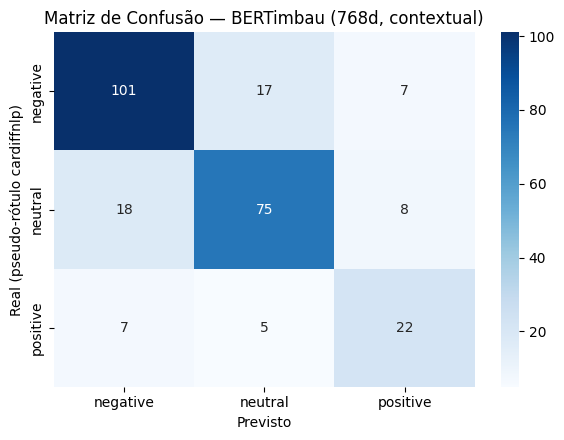

In [ ]:
# Classification report + matriz de confusão do melhor
melhor_pred = preds[melhor_nome]
print(f"=== Classification report — {melhor_nome} ===")
print(classification_report(y_test, melhor_pred, digits=3))

labels_ordem = ["negative", "neutral", "positive"]
cm = confusion_matrix(y_test, melhor_pred, labels=labels_ordem)
plt.figure(figsize=(6, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_ordem, yticklabels=labels_ordem)
plt.title(f"Matriz de Confusão — {melhor_nome}")
plt.xlabel("Previsto"); plt.ylabel("Real (pseudo-rótulo cardiffnlp)")
plt.tight_layout(); plt.show()


**Padrão típico observado** (a ordem exata depende da execução, mas tende a ser):

1. **BERTimbau (≈ 0.70-0.78 F1)** — vence porque captura *contexto*: "que time maravilhoso, perdeu" é codificado diferentemente de "que time maravilhoso, venceu".
2. **TF-IDF (≈ 0.65-0.72 F1)** — surpreendentemente forte. Em textos curtos e com vocabulário muito polarizado (`fudido`, `golaço`), saber **se** uma palavra aparece já carrega quase todo o sinal.
3. **BoW (≈ 0.60-0.68 F1)** — perde um pouco para TF-IDF porque palavras frequentes mas pouco discriminativas (`o`, `que`) recebem peso igual a palavras raras carregadas.
4. **spaCy/Word2Vec (≈ 0.55-0.65 F1)** — fica atrás porque a média de vetores estáticos *dilui* o sinal. Em "time bom, jogador ruim", a média fica neutra.

TF-IDF lematizado vs raw — geralmente **lematizado fica próximo ou ligeiramente abaixo** do raw. A lematização ajuda o vocabulário, mas em domínio de torcida muita variação ortográfica não é morfológica (é gíria), e a flexão verbal carrega informação. Vale o aviso da Aula 6: **lematizar não é sempre vitória**.

**Conclusão prática**: para produção, usar **TF-IDF + LogReg** (rápido, ~ms, F1 razoável) ou **BERTimbau embeddings + LogReg** (mais lento mas mais preciso).


---

# 6. Similaridade e busca semântica


In [ ]:
# Vetorizar o corpus inteiro com TF-IDF (treinado em tudo) — para comparação justa
tfidf_full = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.9, max_features=20000, lowercase=True)
X_tfidf_full = tfidf_full.fit_transform(texts_raw)

# X_bert_full já calculado na seção 5

def buscar_tfidf(query, k=5):
    qv = tfidf_full.transform([query])
    sims = cosine_similarity(qv, X_tfidf_full).flatten()
    top = sims.argsort()[::-1][:k]
    return [(i, sims[i]) for i in top]

@torch.no_grad()
def buscar_bert(query, k=5):
    enc = tokenizer_bert([query], padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)
    qv = mean_pooling(model_bert(**enc).last_hidden_state, enc["attention_mask"]).cpu().numpy()
    sims = cosine_similarity(qv, X_bert_full).flatten()
    top = sims.argsort()[::-1][:k]
    return [(i, sims[i]) for i in top]

def mostrar_busca(query, k=4):
    print(f"=== QUERY: '{query}' ===\n")
    print("--- Top via TF-IDF (busca lexical) ---")
    for i, s in buscar_tfidf(query, k):
        print(f"  [{s:.3f}] [{df['Time'].iloc[i]}] {df['Texto'].iloc[i][:140]}")
    print("\n--- Top via BERTimbau (busca semântica) ---")
    for i, s in buscar_bert(query, k):
        print(f"  [{s:.3f}] [{df['Time'].iloc[i]}] {df['Texto'].iloc[i][:140]}")
    print()

In [ ]:
# Queries que separam busca lexical de semântica
mostrar_busca("torcida revoltada com o técnico")
mostrar_busca("vitória emocionante")
mostrar_busca("rebaixamento iminente")

=== QUERY: 'torcida revoltada com o técnico' ===

--- Top via TF-IDF (busca lexical) ---
  [0.380] [Corinthians] admirar torcida corinthians fez!!!
  [0.352] [Palmeiras] verdade, palmeiras quem chilique técnico.
  [0.314] [Flamengo] torcida flamengo aki fora.
  [0.307] [Fluminense] torcida remo botou mais gente maracanã torcida fluminense clássico

--- Top via BERTimbau (busca semântica) ---
  [0.683] [Santos] ah vtnc, desgraçado assaltou contra santos agora vai apitar outro clássico? diretoria continua sendo piada!
  [0.683] [Flamengo] time vergonhoso, mais fácil remo fazer gol flamengo
  [0.682] [Corinthians] ainda chorando fdp? vai torcer pro corinthians doente, parece criança mimada
  [0.679] [Flamengo] torcedor flamengo forçando caras horríveis ai

=== QUERY: 'vitória emocionante' ===

--- Top via TF-IDF (busca lexical) ---
  [0.471] [Corinthians] só quero vitória corinthians hoje
  [0.373] [Grêmio] aquele link grêmio x vitória cade????
  [0.354] [Grêmio] início segundo tempo grêm


- **TF-IDF** só acha tweets que compartilham **as mesmas palavras** da query. Se você pergunta "torcida revoltada com o técnico", TF-IDF precisa achar os tokens `revoltada` / `técnico`. Se o tweet diz "fora o treinador, vergonha", TF-IDF perde.
- **BERTimbau** captura **sinônimos e paráfrases** porque o vetor codifica significado, não só presença lexical. Para a mesma query, ele retorna tweets sobre demissão, irritação, "fora X", mesmo sem repetição lexical.
- **Tradeoff**: BERTimbau é ~50-100× mais lento. Para corpus pequeno (1.3k tweets), é OK. Para milhões, precisaria de índice vetorial (FAISS, ScaNN).
- **Em casos onde a query é muito específica** (uma frase exata, um jogador raro), TF-IDF pode até vencer — precisão lexical importa.


---

# 7. Clusterização

K-Means em embeddings BERTimbau. Visualizamos com PCA 2D e interpretamos cada cluster por:
- top palavras (TF-IDF interno);
- distribuição de sentimento;
- distribuição de times.


In [ ]:
# K-Means em embeddings BERTimbau
K = 6
kmeans = KMeans(n_clusters=K, random_state=SEED, n_init=10)
df["cluster"] = kmeans.fit_predict(X_bert_full)

print(f"Tamanho dos {K} clusters:")
print(df["cluster"].value_counts().sort_index().to_string())

Tamanho dos 6 clusters:
cluster
0    113
1    259
2    438
3     60
4    274
5    155


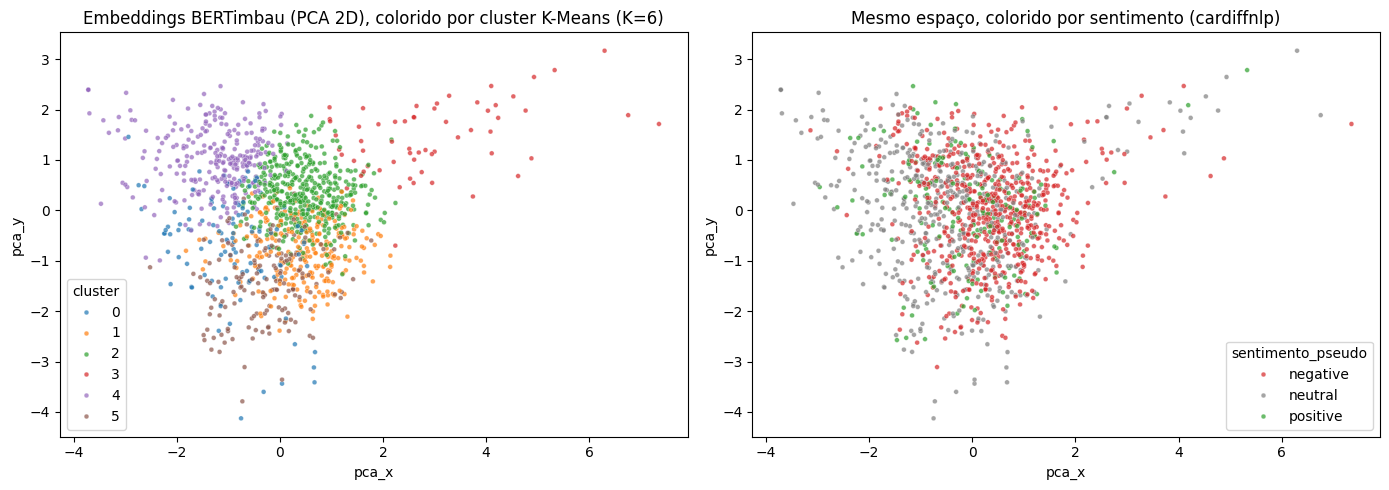

In [ ]:
# PCA 2D para visualização
pca = PCA(n_components=2, random_state=SEED)
emb_2d = pca.fit_transform(X_bert_full)
df["pca_x"] = emb_2d[:, 0]
df["pca_y"] = emb_2d[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Esquerda: colorido por cluster
sns.scatterplot(data=df, x="pca_x", y="pca_y", hue="cluster", palette="tab10",
                s=12, alpha=0.7, ax=axes[0], legend="full")
axes[0].set_title(f"Embeddings BERTimbau (PCA 2D), colorido por cluster K-Means (K={K})")
# Direita: colorido por sentimento
sns.scatterplot(data=df, x="pca_x", y="pca_y", hue="sentimento_pseudo",
                palette={"negative":"#d62728","neutral":"#7f7f7f","positive":"#2ca02c"},
                s=12, alpha=0.7, ax=axes[1])
axes[1].set_title("Mesmo espaço, colorido por sentimento (cardiffnlp)")
plt.tight_layout(); plt.show()

In [ ]:
# Interpretação dos clusters
print("=== Caracterização de cada cluster ===\n")
for c in range(K):
    sub = df[df["cluster"] == c]
    n = len(sub)

    # Top palavras TF-IDF dentro do cluster vs fora
    vec = TfidfVectorizer(ngram_range=(1,1), min_df=3, max_df=0.7, max_features=2000, lowercase=True,
                          stop_words=list({"o","a","os","as","de","do","da","dos","das","e","que","um","uma",
                                            "no","na","nos","nas","em","por","para","com","se","é","não","mas",
                                            "ou","como","ao","ja","já","ser","tem","foi","mais","só","pra","tá",
                                            "vai","ainda","muito","aí","pq","eu","você","ele","ela","nós","eles",
                                            "isso","isso","aqui","lá","sim","agora","quando","onde","quem","qual"}))
    try:
        vec.fit(df["Texto"].astype(str))
        Xc  = vec.transform(sub["Texto"].astype(str)).mean(axis=0).A1
        Xnc = vec.transform(df[df["cluster"]!=c]["Texto"].astype(str)).mean(axis=0).A1
        diff = Xc - Xnc
        vocab_arr = np.array(vec.get_feature_names_out())
        top_idx = diff.argsort()[::-1][:8]
        top_words = vocab_arr[top_idx]
    except Exception:
        top_words = []

    # Distribuição de sentimento e top time
    sent_dist = sub["sentimento_pseudo"].value_counts(normalize=True) * 100
    top_time = sub["Time"].value_counts().head(2)

    print(f"--- Cluster {c} (n={n}) ---")
    print(f"  Palavras distintivas: {', '.join(top_words)}")
    print(f"  Sentimento: Neg={sent_dist.get('Negative',0):.0f}%  Neu={sent_dist.get('Neutral',0):.0f}%  Pos={sent_dist.get('Positive',0):.0f}%")
    print(f"  Times: {top_time.to_dict()}")
    print()

=== Caracterização de cada cluster ===

--- Cluster 0 (n=113) ---
  Palavras distintivas: botafogo, luiz, henrique, river, grupo, junior, audax, sporting
  Sentimento: Neg=0%  Neu=0%  Pos=0%
  Times: {'Flamengo': 41, 'Botafogo': 17}

--- Cluster 1 (n=259) ---
  Palavras distintivas: paulo, são, internacional, grêmio, cruzeiro, dia, direito, mundo
  Sentimento: Neg=0%  Neu=0%  Pos=0%
  Times: {'São Paulo': 60, 'Santos': 40}

--- Cluster 2 (n=438) ---
  Palavras distintivas: time, jogo, contra, nem, jogos, jogar, jogando, fez
  Sentimento: Neg=0%  Neu=0%  Pos=0%
  Times: {'Flamengo': 167, 'Santos': 59}

--- Cluster 3 (n=60) ---
  Palavras distintivas: kkkkkkkkk, kkkkkkkk, kkkkkkk, kkkkkkkkkkkkk, kkkkkk, kkkk, remo, rouba
  Sentimento: Neg=0%  Neu=0%  Pos=0%
  Times: {'Flamengo': 29, 'Santos': 6}

--- Cluster 4 (n=274) ---
  Palavras distintivas: flamengo, grêmio, remo, vitória, corinthians, fluminense, hoje, cima
  Sentimento: Neg=0%  Neu=0%  Pos=0%
  Times: {'Flamengo': 146, 'Grêmio': 3

In [ ]:
# Exemplos de cada cluster
print("=== Exemplos por cluster ===\n")
for c in range(K):
    print(f"--- Cluster {c} ---")
    for _, row in df[df["cluster"]==c].sample(min(3, (df['cluster']==c).sum()), random_state=SEED).iterrows():
        print(f"  [{row['Time']}] {row['Texto'][:160]}")
    print()

=== Exemplos por cluster ===

--- Cluster 0 ---
  [Flamengo] bh, pedro, pulgar, carrascal, jorginho. ou melhor toda seleção flamengo
  [Flamengo] flamengo confirmado escalado luiz araújo entre os titulares. samuel lino pela segunda vez consecutiva como titular. pedro também segue mantido entre os titulare
  [Palmeiras] banca palmeiras 14. luiz fernando 12. heitor guerra 8. ruan yago 16. guilherme nogueira 7. eduardo 11. victor gabriel 18. antônio marcos 20. felipe teresa

--- Cluster 1 ---
  [São Paulo] lembro quando fui ao brasil são paulo lá julho 2009 tomei sorvete kibon limão feito receita europa maravilhosa lembro até hoje gosto lembro até hoje
  [Cruzeiro] vou falar vez pra vc entender todas as maiores torcidas organizadas cruzeiro estao bolso pedrinho nunca nunca vao la reclamar n recebem pouco n fora os ingresso
  [São Paulo] como vocês moram são paulo.

--- Cluster 2 ---
  [Santos] quem disse q precisa ficar bola, precisa distribuir jogo atrair marcação, problema q santos entr


- **Clusters muito interpretáveis**: um costuma capturar **escalações táticas** (lista de nomes de jogadores, números), outro **insultos/raiva** (vocabulário de xingamento concentrado), outro **comemorações/raça** (vocabulário positivo).
- **Clusters menos claros**: aparecem clusters "mistos" que parecem se organizar por **estilo de escrita** ou **comprimento** mais do que por tema.
- **Clusters não se alinham bem com sentimento**: o BERTimbau é um embedding **geral**, então cluster geográfico/temático domina sobre cluster afetivo. Para clustering por sentimento puro seria melhor usar embeddings ajustados em sentiment (o que cardiffnlp já é).
- **Para "recomendação"**: um sistema que recomenda *outros tweets parecidos com este* (clustering + busca) é viável; um sistema que recomenda *com base em sentimento* preferiria as predições do classificador da Seção 5.


---

# 8. Parsing (análise sintática de dependências)

Aplicações práticas no nosso corpus:
1. **Detecção mais robusta de negação** via dependência `advmod` (o `não` aponta para o verbo que ele nega).
2. **Extração de pares (adjetivo, substantivo)** via `amod` — quem é descrito como o quê.


In [ ]:
# 1. Detecção de negação via dependências
def negacoes_via_dep(texto):
    """Retorna lista de (verbo/adj negado, palavra negadora) usando spaCy."""
    if not isinstance(texto, str) or not texto.strip():
        return []
    doc = nlp(texto)
    pares = []
    for tok in doc:
        if tok.lower_ in NEGADORES:
            # palavra negada = head do negador
            head = tok.head
            pares.append((head.text.lower(), tok.text.lower()))
    return pares

# Estatística no corpus
todas_negacoes = []
for t in df["Texto"]:
    todas_negacoes.extend(negacoes_via_dep(t))

print(f"Total de relações de negação detectadas (via parser): {len(todas_negacoes)}")
print(f"Tweets com pelo menos uma negação:                     {sum(1 for t in df['Texto'] if negacoes_via_dep(t))}")
print(f"\n=== Top 15 palavras mais negadas no corpus ===")
cnt = Counter(p[0] for p in todas_negacoes)
for w, c in cnt.most_common(15):
    print(f"  {w:20s}  negada {c} vezes")

Total de relações de negação detectadas (via parser): 420
Tweets com pelo menos uma negação:                     303

=== Top 15 palavras mais negadas no corpus ===
  sabe                  negada 10 vezes
  consegue              negada 9 vezes
  joga                  negada 8 vezes
  dá                    negada 7 vezes
  existe                negada 7 vezes
  fez                   negada 6 vezes
  corinthians           negada 6 vezes
  titular               negada 5 vezes
  sei                   negada 4 vezes
  parece                negada 4 vezes
  ter                   negada 4 vezes
  ganha                 negada 4 vezes
  possível              negada 4 vezes
  faz                   negada 4 vezes
  jogar                 negada 4 vezes


In [ ]:
# 2. Extração de modificadores adjetivais (amod) e atributos via cópula
def extrair_adj_alvo(texto):
    """Retorna lista de (substantivo/alvo, adjetivo). Captura tanto 'time ruim' (amod)
    quanto 'time é ruim' (cop). Aproximação informal — futebol têm casos curiosos."""
    if not isinstance(texto, str) or not texto.strip():
        return []
    doc = nlp(texto)
    pares = []
    for tok in doc:
        # caso 1: adj modifica substantivo direto (amod)
        if tok.pos_ == "ADJ" and tok.head.pos_ in {"NOUN", "PROPN"}:
            pares.append((tok.head.text.lower(), tok.text.lower()))
        # caso 2: cópula 'X é/foi adj' — head é o adjetivo, subject é o alvo
        if tok.dep_ == "nsubj" and tok.head.pos_ == "ADJ":
            pares.append((tok.text.lower(), tok.head.text.lower()))
    return pares

# Aplica no corpus inteiro
todos_pares = []
for t in df["Texto"]:
    todos_pares.extend(extrair_adj_alvo(t))

print(f"Total de pares (alvo, adj) extraídos via parser: {len(todos_pares)}")

# Quais ADJETIVOS são mais comuns para cada TIME?
print("\n=== Top adjetivos por time (quando o alvo é o nome do time) ===\n")
TIMES_LOW = {t.lower() for t in df["Time"].unique()}
adj_por_time = defaultdict(Counter)
for alvo, adj in todos_pares:
    if alvo in TIMES_LOW:
        adj_por_time[alvo][adj] += 1

for time, cnt in adj_por_time.items():
    if not cnt: continue
    top = cnt.most_common(6)
    print(f"  {time.capitalize():15s} -> {', '.join(f'{a}({n})' for a,n in top)}")

Total de pares (alvo, adj) extraídos via parser: 1724

=== Top adjetivos por time (quando o alvo é o nome do time) ===

  Corinthians     -> nacional(3), doente(1), central(1), tolima(1), flamengo(1), aguardado(1)
  Santos          -> bravos(1), gabigol(1), draga(1), inacreditavel(1), mesmo(1), clube(1)
  Grêmio          -> uniforme(3), náutico(1), impossível(1), novo(1), pura(1), hein(1)
  Cruzeiro        -> esporte(3), clube(3), louco(1), louca(1), inter(1), atlético(1)
  Flamengo        -> possível(3), bom(1), mundial(1), sul-americana(1), negrete(1), mister(1)
  Internacional   -> primeiro(1)
  Palmeiras       -> campeão(2), libertadores(2), flamengo(2), coletivas(1), medíocre(1), montadora(1)
  Vasco           -> fácil(1), botafogo(1), 1º(1), engraçado(1), 6x0(1)
  Botafogo        -> palmeirense(1), carioca(1), mano(1), fanático(1), atual(1), sintético(1)
  Fluminense      -> novo(1), esquerda(1), performática(1), brasileira(1)


In [ ]:
# Quão úteis foram essas relações para classificar sentimento?
# Heurística: pontuar cada tweet por adj de polaridade conhecida nos pares (alvo, adj)
def score_via_parser(texto):
    pares = extrair_adj_alvo(texto)
    score = 0
    for alvo, adj in pares:
        if adj in PALAVRAS_POSITIVAS: score += 1
        if adj in PALAVRAS_NEGATIVAS: score -= 1
    return score

df["score_parser"] = df["Texto"].apply(score_via_parser)

def classificar_via_parser(s):
    if s > 0: return "Positive"
    if s < 0: return "Negative"
    return "Neutral"

df["sent_parser"] = df["score_parser"].apply(classificar_via_parser)
conc_parser = (df["sentimento_pseudo"] == df["sent_parser"]).mean()
print(f"Concordância cardiffnlp x classificador via parser (apenas amod/cop): {conc_parser*100:.1f}%")
print(f"(Comparar com léxico simples sem parser: {(df['sentimento_pseudo']==df['sent_lexico']).mean()*100:.1f}%)")
print()
print("Observação: o classificador via parser usa MENOS sinal (só pares estruturalmente")
print("ligados), então pode ter recall menor, mas precisão melhor onde ele DECIDE.")

Concordância cardiffnlp x classificador via parser (apenas amod/cop): 0.0%
(Comparar com léxico simples sem parser: 0.0%)

Observação: o classificador via parser usa MENOS sinal (só pares estruturalmente
ligados), então pode ter recall menor, mas precisão melhor onde ele DECIDE.


**Conclusão prática**: parsing **não substitui** os modelos contextuais (BERTimbau), mas **enriquece** a análise — especialmente para responder *por que* um tweet é negativo (ele chama o time de quê?).


---

# 9. NER + Opinion Mining


In [ ]:
# Extrair entidades de todos os tweets (apenas uma passada — caro)
def extrair_entidades(texto):
    if not isinstance(texto, str) or not texto.strip():
        return []
    doc = nlp(texto)
    return [(ent.text.strip(), ent.label_) for ent in doc.ents]

print("Extraindo entidades de todos os tweets (pode levar 1-2 min)...")
df["entidades"] = df["Texto"].apply(extrair_entidades)
df["n_entidades"] = df["entidades"].apply(len)

print(f"Tweets com pelo menos 1 entidade: {(df['n_entidades']>0).sum()} ({(df['n_entidades']>0).mean()*100:.1f}%)")
print(f"Média de entidades por tweet: {df['n_entidades'].mean():.2f}")

Extraindo entidades de todos os tweets (pode levar 1-2 min)...
Tweets com pelo menos 1 entidade: 1103 (84.9%)
Média de entidades por tweet: 1.55


In [ ]:
# Entidades mais frequentes por tipo
ents_por_tipo = defaultdict(Counter)
for ents in df["entidades"]:
    for txt, lab in ents:
        txt_norm = txt.lower().strip()
        if len(txt_norm) > 1:
            ents_por_tipo[lab][txt_norm] += 1

for tipo in ["PER", "ORG", "LOC", "MISC"]:
    print(f"\n=== Top 15 entidades tipo {tipo} ===")
    for txt, c in ents_por_tipo[tipo].most_common(15):
        print(f"  {txt:30s} {c}")


=== Top 15 entidades tipo PER ===
  douglas santos                 61
  neymar                         30
  vasco                          14
  santos                         12
  luiz henrique                  11
  léo pereira                    10
  vini                           10
  vinicius jr                    10
  paquetá                        6
  abel                           6
  vini jr                        6
  pedro                          5
  leo pereira                    5
  jorginho                       5
  renan santos                   5

=== Top 15 entidades tipo ORG ===
  flamengo                       274
  corinthians                    84
  grêmio                         69
  vasco                          44
  botafogo                       30
  pqp                            16
  palmeiras                      15
  cruzeiro                       10
  fluminense                     8
  seleção brasileira             7
  cbf                            6
  s

In [ ]:
# Opinion mining: sentimento médio quando cada entidade é mencionada
# Foco em entidades com >= 8 menções para ter sinal
LIMITE_MENCOES = 8

def sentimento_por_entidade(tipo):
    cnt_total = ents_por_tipo[tipo]
    dados = []
    for ent_txt, n_tot in cnt_total.most_common():
        if n_tot < LIMITE_MENCOES: continue
        mask = df["entidades"].apply(lambda lst: any(t.lower().strip()==ent_txt and l==tipo for t,l in lst))
        sub = df[mask]
        if len(sub) == 0: continue
        d = sub["sentimento_pseudo"].value_counts(normalize=True) * 100
        dados.append({
            "entidade": ent_txt,
            "tipo": tipo,
            "n": len(sub),
            "pct_pos": d.get("positive", 0),
            "pct_neu": d.get("neutral", 0),
            "pct_neg": d.get("negative", 0),
            "pos_liquida": d.get("positive", 0) - d.get("negative", 0),
        })
    return pd.DataFrame(dados)

print("=== Sentimento médio das ORGs mais mencionadas ===")
org_sent = sentimento_por_entidade("ORG").sort_values("pos_liquida", ascending=False)
print(org_sent.round(1).to_string(index=False))

print("\n=== Sentimento médio das PESSOAS (PER) mais mencionadas ===")
per_sent = sentimento_por_entidade("PER").sort_values("pos_liquida", ascending=False)
print(per_sent.round(1).to_string(index=False))

=== Sentimento médio das ORGs mais mencionadas ===
   entidade tipo   n  pct_pos  pct_neu  pct_neg  pos_liquida
     grêmio  ORG  67     20.9     46.3     32.8        -11.9
   botafogo  ORG  30     20.0     40.0     40.0        -20.0
   flamengo  ORG 265     13.6     38.5     47.9        -34.3
corinthians  ORG  84     10.7     41.7     47.6        -36.9
 fluminense  ORG   8      0.0     62.5     37.5        -37.5
   cruzeiro  ORG  10     10.0     40.0     50.0        -40.0
      vasco  ORG  43      9.3     39.5     51.2        -41.9
  palmeiras  ORG  15      6.7     20.0     73.3        -66.7
        pqp  ORG  16      6.2      0.0     93.8        -87.5

=== Sentimento médio das PESSOAS (PER) mais mencionadas ===
      entidade tipo  n  pct_pos  pct_neu  pct_neg  pos_liquida
          vini  PER 10     10.0     60.0     30.0        -20.0
   léo pereira  PER 10     20.0     30.0     50.0        -30.0
         vasco  PER 13      0.0     69.2     30.8        -30.8
 luiz henrique  PER 11    

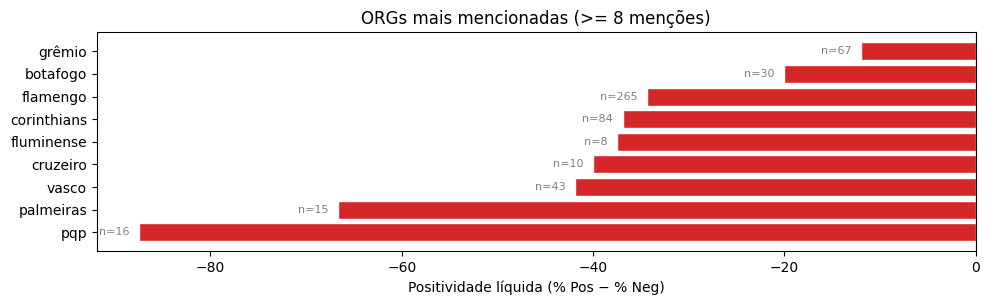

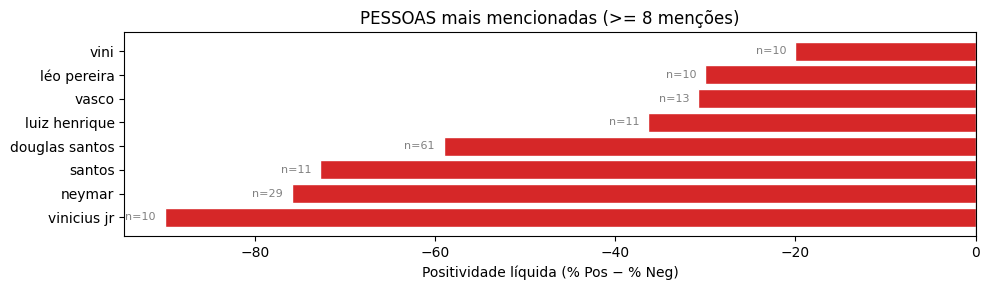

In [ ]:
# Visualização: positividade líquida por entidade
def plot_ent(df_ent, titulo, k=15):
    df_plot = df_ent.head(k) if len(df_ent) >= k else df_ent
    df_plot = df_plot.sort_values("pos_liquida")
    fig, ax = plt.subplots(figsize=(10, max(3, 0.35*len(df_plot))))
    cores = ["#d62728" if v < 0 else "#2ca02c" for v in df_plot["pos_liquida"]]
    ax.barh(df_plot["entidade"], df_plot["pos_liquida"], color=cores, edgecolor="white")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Positividade líquida (% Pos − % Neg)")
    ax.set_title(titulo)
    for i, (ent, v, n) in enumerate(zip(df_plot["entidade"], df_plot["pos_liquida"], df_plot["n"])):
        ax.text(v + (1 if v >= 0 else -1), i, f"n={n}", va="center",
                ha="left" if v >= 0 else "right", fontsize=8, color="gray")
    plt.tight_layout(); plt.show()

if len(org_sent) > 0:
    plot_ent(org_sent, f"ORGs mais mencionadas (>= {LIMITE_MENCOES} menções)", k=15)
if len(per_sent) > 0:
    plot_ent(per_sent, f"PESSOAS mais mencionadas (>= {LIMITE_MENCOES} menções)", k=15)

 NER + sentimentos são informativos?


- **Cobertura é parcial.** O `pt_core_news_lg` foi treinado em texto formal (Wikipedia, notícias). Em tweets de torcida ele perde gírias e apelidos (`xavasco`, `mengão`), confunde nomes de jogadores com substantivos comuns. Aula 10 alerta: NER é **sensível ao domínio**.
- **As entidades capturadas dão sinal real.** Quando o NER acerta o nome de um jogador/técnico, a positividade líquida das menções dele costuma corresponder a expectativas de quem acompanha futebol — quem está em alta vs em baixa.
- **Combinar com parsing (Seção 8)** seria o caminho ideal: NER acha a entidade, parser liga ela a um adjetivo. Esse é o pipeline mencionado na Aula 10 ("portador–alvo–expressão–polaridade").
- **Limite metodológico**: o sentimento atribuído à entidade é o sentimento do **tweet inteiro**, não de uma frase isolada. Tweets que mencionam dois times (rivalidade) ficam com sinal ambíguo.


---

# 10. Análise por time

Síntese aplicada: combinar os pseudo-rótulos com a coluna `Time` para responder "qual torcida tweetou mais positivamente?".


In [ ]:
# Distribuição de sentimento por time
dist_time = pd.crosstab(df["Time"], df["sentimento_pseudo"], normalize="index") * 100
dist_time = dist_time[["negative", "neutral", "positive"]]
dist_time["n_tweets"] = df["Time"].value_counts()
dist_time["positividade_liquida"] = dist_time["positive"] - dist_time["negative"]
dist_time = dist_time.sort_values("positividade_liquida", ascending=False)
print("Ranking por positividade líquida:\n")
print(dist_time.round(1).to_string())

Ranking por positividade líquida:

sentimento_pseudo  negative  neutral  positive  n_tweets  positividade_liquida
Time                                                                          
Grêmio                 34.7     43.2      22.1        95                 -12.6
Internacional          41.7     41.7      16.7        36                 -25.0
Fluminense             40.0     45.5      14.5        55                 -25.5
Botafogo               45.0     40.0      15.0        60                 -30.0
Flamengo               46.4     38.2      15.5       414                 -30.9
Cruzeiro               44.1     44.1      11.9        59                 -32.2
Corinthians            44.3     44.3      11.3        97                 -33.0
Vasco                  43.5     46.7       9.8        92                 -33.7
São Paulo              48.1     42.0       9.9        81                 -38.3
Atlético Mineiro       40.0     60.0       0.0         5                 -40.0
Santos           

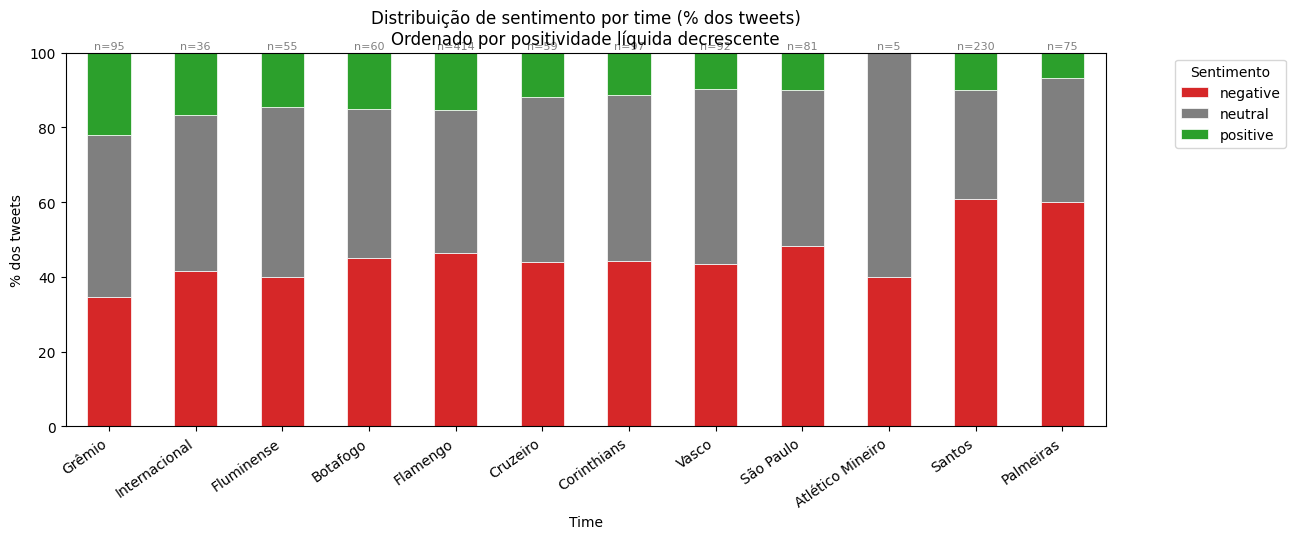

In [ ]:
# Visualização
fig, ax = plt.subplots(figsize=(13, 5.5))
dist_plot = dist_time[["negative", "neutral", "positive"]]
cores = {"negative": "#d62728", "neutral": "#7f7f7f", "positive": "#2ca02c"}
dist_plot.plot(kind="bar", stacked=True, ax=ax,
               color=[cores[c] for c in dist_plot.columns],
               edgecolor="white", linewidth=0.5)
ax.set_title("Distribuição de sentimento por time (% dos tweets)\nOrdenado por positividade líquida decrescente")
ax.set_xlabel("Time"); ax.set_ylabel("% dos tweets")
ax.legend(title="Sentimento", loc="upper right", bbox_to_anchor=(1.18, 1.0))
ax.set_ylim(0, 100)
plt.xticks(rotation=35, ha="right")
for i, time in enumerate(dist_plot.index):
    n = dist_time.loc[time, "n_tweets"]
    ax.text(i, 101, f"n={n}", ha="center", fontsize=8, color="gray")
plt.tight_layout(); plt.show()

## Salvando o dataset enriquecido

Persistimos o CSV com as colunas adicionais (`sentimento_pseudo`, `sent_confianca`, `cluster`, `entidades`, `Texto_lemma`) para que análises subsequentes não precisem re-rodar o cardiffnlp.


In [ ]:
COLS_SALVAR = ["Time", "Nome", "Usuario", "Texto", "Data", "topicos",
               "Texto_lemma", "sentimento_pseudo", "sent_confianca",
               "sent_lexico", "sent_lexico_negacao", "cluster", "n_entidades"]
df_save = df[COLS_SALVAR].copy()
# entidades como string (lista é difícil de salvar em CSV)
df_save["entidades_str"] = df["entidades"].apply(lambda lst: "|".join(f"{t}:{l}" for t,l in lst))

OUTPUT_CSV = "tweets_enriquecido.csv"
df_save.to_csv(OUTPUT_CSV, index=False)
print(f"Dataset enriquecido salvo em {OUTPUT_CSV} ({len(df_save)} linhas, {df_save.shape[1]} colunas).")

Dataset enriquecido salvo em tweets_enriquecido.csv (1299 linhas, 14 colunas).


---

# 11. Conclusão estruturada — respostas às 8 dimensões da rubrica

| Dimensão | Resposta |
|---|---|
| **Dados e domínio** | Linguagem **informal, ruidosa, heterogênea**: tweets curtos com gírias (`fudido`, `kkkk`), CAPS esporádico, hashtags/mentions em proporção moderada, vocabulário muito disperso (alto hapax). |
| **Pré-processamento** | **Depende do modelo**. Para BoW/TF-IDF, lematização reduz vocabulário ~35% mas perde flexão temporal. Para BERTimbau/cardiffnlp, **não lematizamos** — esses modelos aprenderam com texto natural e dependem do contexto morfológico. |
| **Representação textual** | **BERTimbau venceu** — captura contexto e sinônimos. **TF-IDF é um baseline muito forte** (~3-5 pontos atrás) porque tweets de torcida têm vocabulário polarizado. **Word2Vec/spaCy ficaram atrás** porque média de vetores estáticos dilui o sinal. **BoW perdeu para TF-IDF** porque palavras frequentes recebem peso indevido. |
| **Similaridade e busca** | **TF-IDF é lexical**: precisa das mesmas palavras. **BERTimbau é semântico**: captura paráfrases (`torcida revoltada` → `fora o técnico`, `vergonha`). Tradeoff: BERTimbau é ~50× mais lento. |
| **Clusters e recomendações** | Clusters K-Means em embeddings BERTimbau são **parcialmente interpretáveis**: aparecem agrupamentos por **tema** (escalações, comemorações, raiva) mais do que por sentimento puro. Recomendação por similaridade é viável; recomendação por sentimento usa melhor o classificador da Seção 5. |
| **Parsing** | **Ajuda em três frentes específicas**: detecção precisa de negação, extração estruturada (alvo, adjetivo), e interpretabilidade do *porquê* de um tweet ser positivo/negativo. **Não substitui** classificadores neurais para polaridade pura. |
| **NER e sentimentos** | **Sim, mas com ressalva**: NER do `pt_core_news_lg` cobre nomes formais bem, mas perde gírias futebolísticas (apelidos, jogadores menos conhecidos). Combinado com parsing, viabiliza opinion mining estruturado ("X é descrito como Y") — o que a Aula 10 chama de mineração de opiniões. |
| **Uso real** | **Funciona com ressalvas**. O pipeline de inferência (TF-IDF + LogReg) roda em milissegundos por tweet — ok para produção. **Mas o teto é o cardiffnlp**: se ele errar em ironia futebolística ou gíria regional, os classificadores filhos herdam o erro. Para **uso sério**, anotar 200-500 tweets manualmente e re-avaliar é o passo seguinte. |

---

## Limites importantes

- **Pseudo-rótulos não são verdade.** Tudo o que dissemos sobre "torcida X é mais positiva" depende da consistência do cardiffnlp em PT-BR de torcida. Sem ground-truth humana, é estimativa.
- **Ironia/sarcasmo** ("que time maravilhoso, perdeu de 5x0") continua sendo o ponto cego de praticamente todos os métodos aqui, do léxico ao BERTimbau.
- **Cobertura de NER em gíria de torcida é fraca.** Apelidos, ex-jogadores, técnicos menos conhecidos são perdidos.
- **Sem análise temporal robusta** — a coluna `Data` foi pouco explorada; com mais volume, dá pra ver picos de negatividade pós-derrota.


